# **BUILDING TRANSFORMER FROM SCRATCH**


**The Architecture :**
            <center>
            <img src = "Complete_transformer.png">
            </center>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math
import torch.nn.functional as F

In [4]:
from datasets import load_dataset
from transformers import AutoTokenizer

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Positional Encoding

Positional Encoding injects information about the relative or absolute position of tokens in the sequence into the embeddings. Without this, a model like a Transformer would treat every token position identically, losing crucial sequential information.

It typically uses sine and cosine functions of different frequencies to encode position. The formulas for the positional encoding are:

$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$

$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$

where:
- $pos$ is the position of the token in the sequence.
- $i$ is the dimension within the embedding vector.
- $d_{model}$ is the dimension of the model's embeddings.


**Positional encoding in the architecture :** 
            <center><img src = "Positional_encoding.png"></center>

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Different frequencies for different embedding dimensions
        # 1 / (10000^(2i/d_model)) = (10000)^(-2i/d_model)
        #= exp(log((10000)^(-2i/d_model))) = exp((-2i/d_model) * log(10000))
        #= exp((2i) * (-log(10000) / d_model))
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)   # even dims → sin
        pe[:, 1::2] = torch.cos(position * div_term)   # odd  dims → cos

        # [1, max_len, d_model] — not a learnable parameter
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [batch_size, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        #slice effectively to extract the positional encodings
        #relevant to the current input sequence's length,
        #resulting in a tensor of shape [1, sequence_length, d_model].
        return self.dropout(x)

### Scaled Dot-Product Attention

This is the core attention mechanism used in the Transformer architecture. It computes the weighted sum of `Value` vectors, where the weights are determined by the similarity between `Query` and `Key` vectors.

The formula for Scaled Dot-Product Attention is:

$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$

Where:
*   $Q$ (Query): The vector representing the element for which we want to find relevant information.
*   $K$ (Key): The vector representing the elements against which we compare the query to find relevance.
*   $V$ (Value): The vector containing the actual information that will be aggregated.
*   $d_k$: The dimension of the `Key` vectors. Dividing by $\sqrt{d_k}$ is a scaling factor that helps prevent the dot products from becoming too large (which can lead to vanishing gradients during softmax). It ensures that the softmax function operates in regions with stable gradients.

**Process:**
1.  **Similarity Score:** Compute the dot product between the `Query` and all `Key` vectors ($QK^T$).
2.  **Scaling:** Divide the scores by $\sqrt{d_k}$.
3.  **Softmax:** Apply a softmax function to get attention weights. This ensures that the weights sum to 1 and are positive, indicating the importance of each value.
4.  **Weighted Sum:** Multiply the attention weights by the `Value` vectors and sum them up. This produces the final output, which is a weighted representation of the input values, focusing on the most relevant parts.

### **Here i have created scaled_dot_product_attention , custom self attention + scaling ... But This will take much to time to be execute and also converge . So insted use Pytorch 's scaled_dot_product_attention for better result .**

**Using my scaled_dot_product_attention**
            <center>
            <img src = "My_scaled_dot_product_attention.png">
            </center>

            
**Using Pytorch's scaled_dot_product_attention Method**
            <center>
            <img src = "Pytorch_scaled_dot_product_attention.png">
            </center>

In [7]:
from typing import Tuple, Optional

def scaled_dot_product_attention(
    query:  torch.Tensor,
    key:    torch.Tensor,
    value:  torch.Tensor,
    mask:   Optional[torch.Tensor] = None
) -> Tuple[torch.Tensor, torch.Tensor]:

    d_k = query.size(-1) # as the dimensions of Q and K are equal

    # Q · Kᵀ  ->  [batch, heads, q_len, k_len]
    scores = torch.matmul(query, key.transpose(-2, -1))

    # Scale — prevents dot products from growing large in high dims
    scaled = scores / math.sqrt(d_k)

    if mask is not None:
        # -1e9 pushes softmax output ≈ 0 for masked positions
        scaled = scaled.masked_fill(mask == 0, -1e9)
        # mask == 0 will result in a boolean tensor
        #where 'True' indicates positions that should be masked (i.e., set to -1e9).

    weights = F.softmax(scaled, dim=-1)           # attention distribution
    output  = torch.matmul(weights, value)        # weighted sum of values

    return output, weights

### Multi-Head Attention

Multi-Head Attention is an extension of the single Scaled Dot-Product Attention mechanism. Instead of performing a single attention function, it projects the queries, keys, and values $h$ times with different, learned linear projections to $d_k$, $d_k$, and $d_v$ dimensions, respectively. For each of these projected versions, it then runs the attention function in parallel.

This allows the model to jointly attend to information from different representation subspaces at different positions. Essentially, each "head" can focus on different aspects of the input sequence, capturing diverse types of relationships and dependencies.

After computing $h$ parallel attention outputs, these are concatenated and once again linearly projected to the desired output dimension, $d_{model}$.

The mathematical representation is as follows:

$MultiHead(Q, K, V) = Concat(head_1, ..., head_h)W^O$

where $head_i = Attention(QW_i^Q, KW_i^K, VW_i^V)$

And the projections are parameter matrices:

$W_i^Q \in \mathbb{R}^{d_{model} \times d_k}$
$W_i^K \in \mathbb{R}^{d_{model} \times d_k}$
$W_i^V \in \mathbb{R}^{d_{model} \times d_v}$
$W^O \in \mathbb{R}^{h d_v \times d_{model}}$

In typical Transformer implementations, $d_k = d_v = d_{model} / h$ to maintain computational efficiency.

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Each head gets its own learned Q, K, V subspace
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)   # output projection
        self.dropout = nn.Dropout(p=dropout)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        B, L, _ = x.size()
        # [B, L, d_model] → [B, heads, L, d_k]
        return x.view(B, L, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, query, key, value, mask=None):

        # [B, L_q, d_model] → [B, heads, L_q, d_k]
        # Q -> [B, L_q, d_model] => [B , 2, 512]
        # W_q -> [d_model, d_model] => [512, 512]
        # Q @ W_q -> [B, L_q, d_model] => [B, 2, 512]
        # self.split_heads -> [B, heads, L_q, d_k] => [B, 8, 2, 64]
        Q = self.split_heads(self.W_q(query))
        K = self.split_heads(self.W_k(key))
        V = self.split_heads(self.W_v(value))

        #out, weights = scaled_dot_product_attention(Q, K, V, mask)
        # Torch implementation better than my scaled_dot_product_attention
        out = F.scaled_dot_product_attention(Q, K, V, attn_mask=mask, dropout_p=self.dropout.p, is_causal=False)
        weights = None
        out = self.dropout(out)

        # Merge all heads: [B, heads, L, d_k] → [B, L, d_model]
        B, _, L, _ = out.size()
        out = out.transpose(1, 2).reshape(B, L, -1)

        return self.W_o(out), weights

### Feed-Forward Network

Each Transformer encoder and decoder block contains a position-wise, fully connected Feed-Forward Network (FFN). This network is applied identically and independently to each position (token) in the sequence.

The FFN consists of two linear transformations with a ReLU activation in between:

$FFN(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$

Where:
*   $x$: The input tensor for a single position, typically of shape `[d_model]` (though processed in parallel for all positions in a batch).
*   $W_1$, $b_1$: Parameters for the first linear transformation. This layer typically expands the dimensionality from $d_{model}$ to a higher dimension, $d_{ff}$ (e.g., $d_{ff} = 4 \times d_{model}$ in the original paper).
*   $\text{ReLU}$: The Rectified Linear Unit activation function, which introduces non-linearity.
*   $W_2$, $b_2$: Parameters for the second linear transformation. This layer contracts the dimensionality back from $d_{ff}$ to $d_{model}$.

**Key Characteristics:**
*   **Position-wise:** The exact same FFN is applied to every single position in the sequence, but each position is processed independently. This means there's no interaction between different positions *within* the FFN itself; their interaction comes from the preceding attention layers.
*   **Expand-Contract:** It uses a "bottleneck" structure, first expanding the feature space (e.g., to 4 times $d_{model}$) and then contracting it back. This allows the model to process what it has gathered through the attention mechanism for each token individually, enriching its representation before passing it to the next layer.

In [9]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        # Bottleneck: d_model → d_ff → d_model
        # In the original paper: d_model=512, d_ff=2048 (4× expansion)
        self.linear1  = nn.Linear(d_model, d_ff)
        self.linear2  = nn.Linear(d_ff,    d_model)
        self.dropout  = nn.Dropout(p=dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [batch_size, seq_len, d_model]
        x = F.relu(self.linear1(x))   # expand + activate
        x = self.dropout(x)
        return self.linear2(x)         # project back

### Encoder Layer

An Encoder Layer (or "Encoder Block") is the fundamental building block of the Transformer encoder. Each encoder layer consists of two main sub-layers:

1.  **Multi-Head Self-Attention Mechanism:** This sub-layer processes the input sequence, allowing each token to attend to all other tokens in the same sequence to capture contextual relationships. In the encoder, this is *self-attention* where Query, Key, and Value all come from the same input.
2.  **Position-wise Feed-Forward Network:** This sub-layer is a simple, fully connected feed-forward network applied independently to each position in the sequence.

**Residual Connections and Layer Normalization:**

Each of these two sub-layers is followed by a **residual connection** and then a **layer normalization**. The order of these operations is crucial and leads to two common variants:

*   **Post-Layer Normalization (Post-LN):** As presented in the original "Attention Is All You Need" paper. The output of each sub-layer is formulated as:

    $x = LayerNorm(x + Sublayer(x))$

    Here, the residual connection is added *before* layer normalization.

*   **Pre-Layer Normalization (Pre-LN):** This variant applies layer normalization *before* the sub-layer function and then adds the residual connection. The formulation becomes:

    $x = x + Sublayer(LayerNorm(x))$

    Pre-LN is often preferred in modern Transformer implementations because it tends to lead to more stable training, especially with deeper models, and allows for higher learning rates.

Where:
*   $x$ is the input to the sub-layer.
*   $Sublayer(x)$ is the output of the sub-layer (either multi-head attention or the feed-forward network).
*   The `+` indicates the residual connection, where the input to the sub-layer is added to its output.
*   `LayerNorm` is applied after this summation in Post-LN or before the sub-layer in Pre-LN.

This notebook's `EncoderLayer` (and `DecoderLayer`) currently implement the **Pre-Layer Normalization** variant for improved training stability.

In [10]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward   = FeedForward(d_model, d_ff, dropout)

        # Two separate LayerNorms — one per sub-layer
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(p=dropout)
        self.dropout2 = nn.Dropout(p=dropout)

        """ The next commented part is the implementation of the original paper.
            It is called Post Layernorm Method
            But Pre layernorm is more efficient . So we are using it instead.
        """

    # def forward(self, x: torch.Tensor, mask=None) -> torch.Tensor:
    #     # 1. Self-attention  (Q = K = V = x)
    #     attn_out, _ = self.self_attention(x, x, x, mask)
    #     x = self.norm1(x + self.dropout1(attn_out))   # residual + LN

    #     # 2. Feed-forward
    #     ff_out = self.feed_forward(x)
    #     x = self.norm2(x + self.dropout2(ff_out))     # residual + LN

    #     return x
    def forward(self, x: torch.Tensor, mask=None) -> torch.Tensor:
        # 1. Self-attention (Normalize BEFORE attention)
        norm_x = self.norm1(x)
        attn_out, _ = self.self_attention(norm_x, norm_x, norm_x, mask)
        x = x + self.dropout1(attn_out)   # Residual AFTER

        # 2. Feed-forward (Normalize BEFORE FFN)
        norm_x2 = self.norm2(x)
        ff_out = self.feed_forward(norm_x2)
        x = x + self.dropout2(ff_out)     # Residual AFTER

        return x

### Encoder

The Encoder in the Transformer architecture is responsible for processing the input sequence and generating a sequence of continuous representations. It is composed of the following main parts:

1.  **Token Embedding:** Converts input tokens (e.g., words, subword units) into dense vector representations. This is a standard `nn.Embedding` layer.

2.  **Positional Encoding:** Adds positional information to the token embeddings. Since the self-attention mechanism is permutation-invariant (meaning it doesn't inherently understand token order), positional encodings are crucial to inject sequence order information.

3.  **Scaling of Embeddings:** The token embeddings are scaled by `√d_model` before adding the positional encodings. This scaling is performed to prevent the positional signal from dominating the magnitude of the embedding values, especially in deeper layers. If the embeddings were very small, adding positional encodings could significantly alter their scale, which might destabilize training.

4.  **Stacked Encoder Layers:** The core of the Encoder is a stack of `N` identical `EncoderLayer` instances. Each `EncoderLayer` contains a Multi-Head Self-Attention mechanism and a Position-wise Feed-Forward Network, each followed by residual connections and layer normalization.

**Overall Data Flow:**

First, the input token IDs are converted into dense embeddings. These embeddings are then scaled and combined with positional encodings. This combined representation is then passed through a stack of `num_layers` encoder layers. Each layer refines the representation by performing self-attention and feed-forward operations, incorporating residual connections and layer normalization at each step. The final output of the Encoder is a sequence of contextualized representations, ready to be passed to the Decoder.

**The architecture for Encoder :**
            <center>
            <img src = "Encoder.png">
            </center>

In [11]:
class Encoder(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, d_ff,
                 vocab_size, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model

        self.token_embedding     = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout)

        # N identical encoder layers
        self.layers  = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x: torch.Tensor, mask=None) -> torch.Tensor:
        # Scale before adding PE so magnitudes are comparable
        x = self.token_embedding(x) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, mask)

        return x   # [batch_size, seq_len, d_model]

### Decoder Layer

A Decoder Layer is a key component of the Transformer decoder, responsible for processing the target sequence and integrating information from the encoder's output. Each decoder layer is composed of three main sub-layers:

   **Masked Multi-Head Self-Attention:** This sub-layer allows each position in the target sequence to attend to all preceding positions in the *same* target sequence, including itself. The masking ensures that predictions for a given position (`i`) can only depend on known outputs at positions less than `i` (causality). This prevents the decoder from

In [12]:
# Mask matrix formation
def create_causal_mask(seq_len: int, device=None) -> torch.Tensor:
    """Lower-triangular mask — position i cannot attend to j > i."""
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
    return mask.unsqueeze(0).unsqueeze(0)   # [1, 1, tgt_len, tgt_len]


class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        # Sub-layer 1: causal self-attention (tgt attends to tgt, past only)
        self.self_attention  = MultiHeadAttention(d_model, num_heads, dropout)
        # Sub-layer 2: cross-attention  (Q=decoder state, K/V=encoder output)
        self.cross_attention = MultiHeadAttention(d_model, num_heads, dropout)
        # Sub-layer 3: position-wise FFN
        self.feed_forward    = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop1 = nn.Dropout(p=dropout)
        self.drop2 = nn.Dropout(p=dropout)
        self.drop3 = nn.Dropout(p=dropout)

        """ The next commented part is the implementation of the original paper.
            It is called Post Layernorm Method
            But Pre layernorm is more efficient . So we are using it instead.
        """

    # def forward(
    #     self,
    #     x:          torch.Tensor,                    # [B, tgt_len, d_model]
    #     enc_output: torch.Tensor,                    # [B, src_len, d_model]
    #     src_mask:   Optional[torch.Tensor] = None,   # encoder padding mask
    #     tgt_mask:   Optional[torch.Tensor] = None,   # causal + padding mask
    # ) -> Tuple[torch.Tensor, torch.Tensor]:

    #     # 1. Masked self-attention — each tgt pos attends only to ≤ itself
    #     sa, _  = self.self_attention(x, x, x, tgt_mask)
    #     x      = self.norm1(x + self.drop1(sa))

    #     # 2. Cross-attention — Q from decoder, K and V from encoder
    #     ca, cw = self.cross_attention(x, enc_output, enc_output, src_mask)
    #     x      = self.norm2(x + self.drop2(ca))

    #     # 3. Feed-forward
    #     ff     = self.feed_forward(x)
    #     x      = self.norm3(x + self.drop3(ff))

    #     return x, cw   # cw shape: [B, heads, tgt_len, src_len]

    def forward(
        self,
        x:          torch.Tensor,
        enc_output: torch.Tensor,
        src_mask:   Optional[torch.Tensor] = None,
        tgt_mask:   Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:

        # 1. Masked self-attention (Normalize BEFORE)
        norm_x = self.norm1(x)
        sa, _  = self.self_attention(norm_x, norm_x, norm_x, tgt_mask)
        x      = x + self.drop1(sa)

        # 2. Cross-attention (Normalize BEFORE)
        norm_x2 = self.norm2(x)
        ca, cw = self.cross_attention(norm_x2, enc_output, enc_output, src_mask)
        x      = x + self.drop2(ca)

        # 3. Feed-forward (Normalize BEFORE)
        norm_x3 = self.norm3(x)
        ff     = self.feed_forward(norm_x3)
        x      = x + self.drop3(ff)

        return x, cw

### Decoder

The Decoder in the Transformer architecture is responsible for generating the target sequence, one token at a time, based on the encoded representation of the input sequence and the previously generated target tokens. It is composed of the following main parts:

1.  **Target Token Embedding:** Converts target tokens (e.g., words, subword units) into dense vector representations. This is a standard `nn.Embedding` layer.

2.  **Positional Encoding:** Adds positional information to the target token embeddings. Similar to the encoder, this is crucial for the model to understand the order of tokens in the target sequence.

3.  **Scaling of Embeddings:** The target token embeddings are scaled by `√d_model` before adding the positional encodings, for the same reasons as in the Encoder (preventing positional signal dominance and stabilizing training).

4.  **Stacked Decoder Layers:** The core of the Decoder is a stack of `N` identical `DecoderLayer` instances. Each `DecoderLayer` contains three sub-layers:
    *   **Masked Multi-Head Self-Attention:** Allows each position in the target sequence to attend to all *preceding* positions in the same target sequence. The masking ensures that predictions for a given position (`i`) can only depend on known outputs at positions less than `i` (causality).
    *   **Multi-Head Cross-Attention:** Allows the decoder to attend to the output of the *encoder*. Here, the Query comes from the previous decoder sub-layer, while the Key and Value come from the encoder's output.
    *   **Position-wise Feed-Forward Network:** A fully connected feed-forward network applied independently to each position.

    Each of these sub-layers is followed by a residual connection and layer normalization.

**Overall Data Flow:**

First, the input target token IDs are converted into dense embeddings, scaled, and combined with positional encodings. This combined representation is then passed through a stack of `num_layers` decoder layers. Each layer refines the representation by performing masked self-attention on the target sequence, cross-attention with the encoder's output, and a feed-forward operation. Residual connections and layer normalization are applied at each step.

The Decoder also **collects cross-attention weights** from each layer. These weights are highly valuable for directly inspecting which source tokens the model attends to when generating each target token, offering insights into the model's decision-making process.

**The Architecture of Decoder :**
                <center>
                <img src = "Decoder.png">
                </center>

In [13]:
class Decoder(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, d_ff,
                 vocab_size, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.token_embedding     = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout)
        self.layers  = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(p=dropout)

    def forward(
        self,
        x:          torch.Tensor,
        enc_output: torch.Tensor,
        src_mask:   Optional[torch.Tensor] = None,
        tgt_mask:   Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, list]:

        x = self.token_embedding(x) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        cross_weights = []
        for layer in self.layers:
            x, cw = layer(x, enc_output, src_mask, tgt_mask)
            cross_weights.append(cw)   # one heatmap per layer for viz

        # x:            [batch_size, tgt_len, d_model]
        # cross_weights: list of N tensors, each [B, heads, tgt_len, src_len]
        return x, cross_weights

### Transformer

The Transformer is a powerful neural network architecture designed for sequence-to-sequence tasks, such as machine translation, text summarization, and more. It is built entirely on attention mechanisms, eschewing recurrent (RNNs) and convolutional (CNNs) layers. The core components are an Encoder and a Decoder.

**Overall Architecture:**

1.  **Encoder:** The encoder processes the input sequence (source language) and transforms it into a continuous representation. It consists of a stack of `num_layers` identical `EncoderLayer` instances. Each `EncoderLayer` contains a Multi-Head Self-Attention mechanism and a Position-wise Feed-Forward Network.

2.  **Decoder:** The decoder generates the output sequence (target language) one token at a time, based on the encoder's output and the previously generated tokens. It also consists of a stack of `num_layers` identical `DecoderLayer` instances. Each `DecoderLayer` features three sub-layers: Masked Multi-Head Self-Attention (for target sequence), Multi-Head Cross-Attention (attending to encoder output), and a Position-wise Feed-Forward Network.

3.  **Output Projection:** The final output of the decoder, which is a sequence of hidden states, is projected onto the target vocabulary space using a linear layer (`output_proj`). A softmax function is typically applied to these logits to obtain probabilities for each token in the target vocabulary.

**Key Characteristics:**

*   **Sequence-to-Sequence:** Designed for tasks where an input sequence is transformed into an output sequence.
*   **Attention-based:** Relies solely on self-attention and cross-attention mechanisms to capture dependencies within and between sequences.
*   **Autoregressive Decoding:** The decoder generates the target sequence token by token, using its own previous outputs as part of the input for the next step.
*   **Xavier Initialization:** All weight matrices in the Transformer are typically initialized using Xavier (Glorot) uniform initialization (`nn.init.xavier_uniform_`). This helps maintain stable gradient flow during training by initializing weights such that the variance of the activations is the same across all layers.

**Data Flow:**

First, the source sequence `src` is fed into the `Encoder`, which produces `enc_out`. This `enc_out` represents a contextualized understanding of the entire source sequence. Then, the decoder takes the target sequence `tgt` (initially starting with a `bos_id` - beginning-of-sequence token) and `enc_out`. It processes `tgt` autoregressively, attending to both past `tgt` tokens and the `enc_out` via cross-attention. The output hidden states `dec_out` are then passed through a linear layer to generate `logits` for the target vocabulary:

$logits = W_{out} \cdot Decoder(tgt, Encoder(src))$

In [14]:
class Transformer(nn.Module):
    def __init__(self,
                 src_vocab_size: int,
                 tgt_vocab_size: int,
                 d_model:    int   = 512,
                 num_heads:  int   = 8,
                 num_layers: int   = 6,
                 d_ff:       int   = 2048,
                 max_len:    int   = 5000,
                 dropout:    float = 0.1):
        super().__init__()
        self.encoder = Encoder(num_layers, d_model, num_heads, d_ff,
                               src_vocab_size, max_len, dropout)
        self.decoder = Decoder(num_layers, d_model, num_heads, d_ff,
                               tgt_vocab_size, max_len, dropout)
        # Project decoder hidden states → target vocabulary logits
        self.output_proj = nn.Linear(d_model, tgt_vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    # THIS IS USED FOR TRAINING (Non-Autoregressive / Parallel Execution)
    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        enc_out          = self.encoder(src, src_mask)
        dec_out, cross_w = self.decoder(tgt, enc_out, src_mask, tgt_mask)
        logits           = self.output_proj(dec_out)   # [B, tgt_len, tgt_vocab]
        return logits, cross_w

    # ── Convenience helpers for autoregressive decoding ──────────────
    def encode(self, src, src_mask=None):
        """Encode the source sequence once; reuse for every decoding step."""
        return self.encoder(src, src_mask)

    def decode(self, tgt, enc_out, src_mask=None, tgt_mask=None):
        """One decoding step — called repeatedly during inference."""
        return self.decoder(tgt, enc_out, src_mask, tgt_mask)

    # Inference execution is Sequential (Autoregressive) by generate method.
    def generate(self, src, src_mask, max_len, bos_id, eos_id):
        #bos_id (Beginning-of-Sequence ID)
        #eos_id (End-of-Sequence ID)
        """Greedy autoregressive generation."""
        enc_out = self.encode(src, src_mask)
        ys = torch.full((src.size(0), 1), bos_id, device=src.device)

        for _ in range(max_len - 1):
            tgt_mask = create_causal_mask(ys.size(1), device=src.device)
            dec_out, _ = self.decode(ys, enc_out, src_mask, tgt_mask)
            next_token = self.output_proj(dec_out[:, -1:]).argmax(-1)
            ys = torch.cat([ys, next_token], dim=1)
            if (next_token == eos_id).all():
                break
        return ys

#Loading the dataset for training .

In [15]:
print("Downloading dataset and tokenizer...")
# We use a 5% slice of the training data just to keep this local test fast
dataset = load_dataset("Helsinki-NLP/opus_books", "en-fr", split="train[:5%]")

# We use the t5-small tokenizer because it is lightweight and handles multiple languages
tokenizer = AutoTokenizer.from_pretrained("t5-small")
PAD_IDX = tokenizer.pad_token_id

README.md:   0%|          | 0.00/28.1k [00:00<?, ?B/s]

en-fr/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/127085 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

In [16]:
def collate_fn(batch):
    en_texts = [item['translation']['en'] for item in batch]
    fr_texts = [item['translation']['fr'] for item in batch]

    # Tokenize Source (English)
    src_encodings = tokenizer(en_texts, padding=True, truncation=True, max_length=64, return_tensors="pt")
    src = src_encodings['input_ids']

    # Tokenize Target (French) - T5 automatically adds an EOS token at the end
    tgt_encodings = tokenizer(fr_texts, padding=True, truncation=True, max_length=64, return_tensors="pt")
    tgt_full = tgt_encodings['input_ids']

    # We must explicitly create the bos_tokens tensor before using it
    batch_size = tgt_full.size(0)
    bos_tokens = torch.full((batch_size, 1), PAD_IDX, dtype=torch.long)


    # tgt_in: [BOS, word1, word2, ...] (Drop the last token to maintain length)
    tgt_in = torch.cat([bos_tokens, tgt_full[:, :-1]], dim=1)

    # tgt_out: [word1, word2, ..., EOS] (What the model must predict)
    tgt_out = tgt_full

    return src.to(device), tgt_in.to(device), tgt_out.to(device)

In [17]:
# Create the DataLoader
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

#Initialize the Transformer Model

In [18]:
# Initialize the Transformer model
d_model = 512
num_heads = 8
num_layers = 6
d_ff = 2048
max_len = 64 # Max sequence length for tokenizer, consistent with collate_fn
dropout = 0.1

model = Transformer(
    src_vocab_size=tokenizer.vocab_size,
    tgt_vocab_size=tokenizer.vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    d_ff=d_ff,
    max_len=max_len,
    dropout=dropout
).to(device) # Move model to the selected device (CPU/GPU)

#Training of the data

In [19]:
from transformers import get_linear_schedule_with_warmup

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
# Lower the base LR slightly; the scheduler will handle the rest
optimizer = optim.Adam(model.parameters(), lr=0.0003)

EPOCHS = 10
loss_history = []
accuracy_history = []

# FIX: Set up the Warmup Scheduler
total_training_steps = len(dataloader) * EPOCHS
# Warm up for the first 10% of training steps
warmup_steps = int(0.1 * total_training_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

print("Starting training on real English-to-French data with Warmup...")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct_tokens = 0
    total_valid_tokens = 0

    for src, tgt_in, tgt_out in dataloader:
        optimizer.zero_grad()

        tgt_mask = create_causal_mask(tgt_in.size(1), device=device)
        logits, _ = model(src, tgt_in, tgt_mask=tgt_mask)


        loss = criterion(logits.reshape(-1, tokenizer.vocab_size), tgt_out.reshape(-1))

        loss.backward()

        # FIX: Clip gradients to prevent severe spikes
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step() # FIX: Step the learning rate scheduler every batch

        total_loss += loss.item()

        predictions = logits.argmax(dim=-1)
        valid_token_mask = (tgt_out != PAD_IDX)
        correct_predictions = ((predictions == tgt_out) * valid_token_mask).sum().item()

        correct_tokens += correct_predictions
        total_valid_tokens += valid_token_mask.sum().item()

    epoch_loss = total_loss / len(dataloader)
    epoch_acc = (correct_tokens / total_valid_tokens) * 100

    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_acc)

    # Print the current Learning Rate alongside metrics to watch it adjust
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | LR: {current_lr:.6f} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Starting training on real English-to-French data with Warmup...
Epoch 01/10 | LR: 0.000300 | Loss: 5.9886 | Accuracy: 15.32%
Epoch 02/10 | LR: 0.000267 | Loss: 4.1652 | Accuracy: 29.86%
Epoch 03/10 | LR: 0.000233 | Loss: 2.0514 | Accuracy: 65.17%
Epoch 04/10 | LR: 0.000200 | Loss: 0.4682 | Accuracy: 91.31%
Epoch 05/10 | LR: 0.000167 | Loss: 0.1776 | Accuracy: 96.48%
Epoch 06/10 | LR: 0.000133 | Loss: 0.0938 | Accuracy: 98.07%
Epoch 07/10 | LR: 0.000100 | Loss: 0.0629 | Accuracy: 98.78%
Epoch 08/10 | LR: 0.000067 | Loss: 0.0475 | Accuracy: 99.12%
Epoch 09/10 | LR: 0.000033 | Loss: 0.0344 | Accuracy: 99.35%
Epoch 10/10 | LR: 0.000000 | Loss: 0.0308 | Accuracy: 99.42%


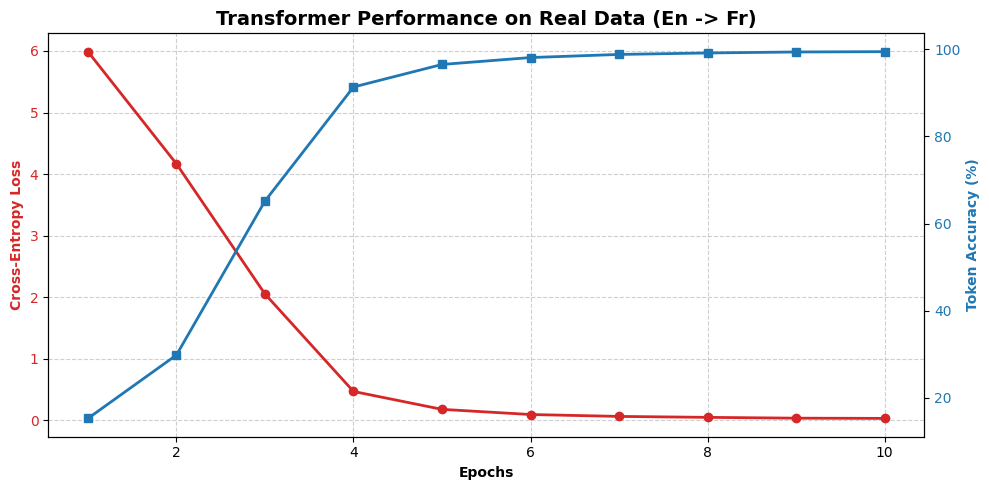

In [20]:
def plot_metrics(losses, accuracies, epochs):
    """Plots training loss and accuracy on a dual-axis graph."""
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # X-axis
    epoch_range = range(1, epochs + 1)
    ax1.set_xlabel('Epochs', fontweight='bold')

    # Primary Y-axis (Loss)
    ax1.set_ylabel('Cross-Entropy Loss', color='tab:red', fontweight='bold')
    ax1.plot(epoch_range, losses, color='tab:red', marker='o', linewidth=2, label='Training Loss')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Secondary Y-axis (Accuracy)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Token Accuracy (%)', color='tab:blue', fontweight='bold')
    ax2.plot(epoch_range, accuracies, color='tab:blue', marker='s', linewidth=2, label='Training Accuracy')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    # Titles and display
    plt.title('Transformer Performance on Real Data (En -> Fr)', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()

# Call the function with our recorded history
plot_metrics(loss_history, accuracy_history, EPOCHS)